# NB 01 — FNet vs Attention vs GP Attention

**Week 38 · The Frequency Domain.** Companion to
[The Frequency Domain: How Fourier Transforms Secretly Powered Everything We Built](https://artifocial.com/blog/frequency-domain-2026-sep-17)
and to the explainer [Bochner's Theorem and the Kernel–Fourier Bridge](https://artifocial.com/blog/bochner-theorem-kernel-fourier-bridge-2026-sep-20).

Pure NumPy. CPU only. Three token-mixing layers, written from scratch with hand-derived gradients,
trained on **one** task and compared on three axes: accuracy, wall-clock scaling, and whether the model
can tell you when it does not know.

| mixer | what it is | learnable in the mixing? | content-dependent? |
|---|---|---|---|
| **Attention** | softmax dot-product over all pairs | yes (Q, K, V, O) | yes |
| **FNet** | 2-D DFT over hidden then sequence, real part | **no parameters at all** | **no** |
| **GP attention** | Nadaraya–Watson regression with an RBF kernel | yes (Q, K, V, O) | yes |

The three are not arbitrary alternatives. Softmax attention *is* kernel regression with an exponentiated
dot-product kernel; swap that for a stationary kernel and Bochner's theorem says it is an expectation over
Fourier features; take the fixed, unlearned limit of a global mixing operation and you get the DFT. This
notebook is about what the differences buy and cost when you measure them.

**A warning about what is being compared.** These are single-layer toy models at $d = 32$ on a synthetic
task, timed on one laptop CPU with NumPy's BLAS. They cannot rank FNet against BERT. What they *can* do —
and what the published benchmarks cannot do as cleanly — is isolate one architectural property at a time
and show exactly which capability disappears with it.

In [1]:
import numpy as np, time, sys
import matplotlib.pyplot as plt
print("python", sys.version.split()[0], "| numpy", np.__version__)
plt.rcParams["figure.dpi"] = 110
rng_global = np.random.default_rng(11)

python 3.14.5 | numpy 2.5.3


---

## 1. One task, two independent bits

Each example is a sequence of `L = 64` vectors in $\mathbb{R}^{32}$, carrying two independent labels that
stress different things.

**The global bit.** The whole sequence is modulated by a sinusoid along the position axis, at either 3 or
11 cycles, with a random phase. Reading this bit requires aggregating across *all* positions in a fixed,
content-independent way. It is, literally, a frequency-detection problem.

**The routing bit.** Position 0 holds a *query* key. Exactly one of the other 63 positions holds a matching
key, and that position — and only that position — carries the answer bit in its value slot. The other 62
positions carry random values. One global functional does leak: planting the answer in a value slot
shifts the sequence-wide sum along the value direction by exactly that bit, and against the noise of 62
random slots that is worth about $\Phi(1/(2\sqrt{15.5})) \approx 0.55$ accuracy for the best fixed
linear read — we derive and measure that ceiling below. Reading the bit *reliably* requires deciding
*which position to look at based on the content*, which is what learned routing is for.

The label is the pair, so there are four classes and chance is 0.250 overall, 0.500 per bit. The whole
design of the task is that a mixer can be excellent at one bit while pinned at the leak ceiling on the other, and the
aggregate accuracy would hide that — so we always report the bits separately.

batch shape (4, 64, 32) labels [2 2 2 0] = 2*global + routing


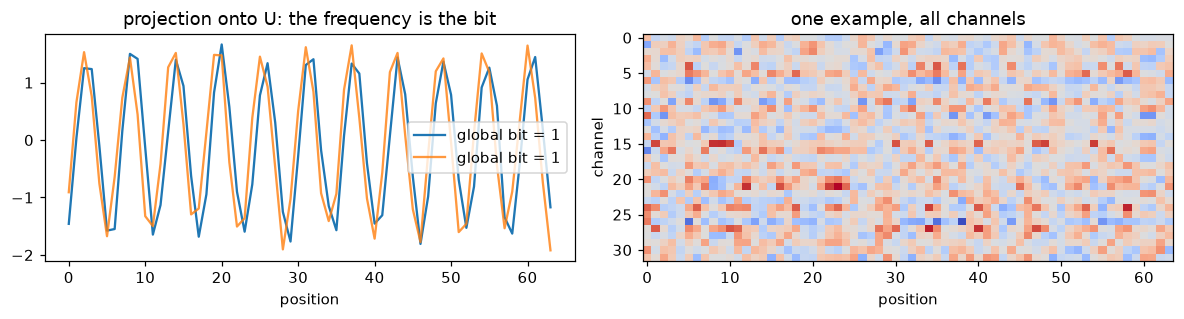

In [2]:
L, D_MODEL, N_KEYS, N_POOL = 64, 32, 8, 4
LS = 4.0                      # RBF lengthscale for GP attention

_r = np.random.default_rng(11)
U      = _r.normal(0, 1, D_MODEL) / np.sqrt(D_MODEL)          # direction of the global sinusoid
V_DIR  = _r.normal(0, 1, D_MODEL) / np.sqrt(D_MODEL) * 2.0    # direction encoding a slot's value bit
Q_FLAG = _r.normal(0, 1, D_MODEL) / np.sqrt(D_MODEL) * 2.0    # marks position 0 as the query
EMB    = _r.normal(0, 1, (N_KEYS, D_MODEL)) / np.sqrt(D_MODEL) * 2.0

def make_batch(n, rng, ood=False):
    bg = rng.integers(0, 2, n)                       # global bit
    br = rng.integers(0, 2, n)                       # routing bit
    f  = np.where(bg == 0, 3.0, 11.0)
    t  = np.arange(L) / L
    ph = rng.uniform(0, 2 * np.pi, n)
    X = (2.0 * np.sin(2 * np.pi * f[:, None] * t[None, :] + ph[:, None]))[:, :, None] * U[None, None, :]

    q = rng.integers(0, N_KEYS, n)
    keys = rng.integers(0, N_KEYS - 1, (n, L))
    keys = keys + (keys >= q[:, None])               # sample uniformly from the keys OTHER than q
    vals = rng.integers(0, 2, (n, L))
    if not ood:
        pos = rng.integers(1, L, n)                  # plant exactly one match
        keys[np.arange(n), pos] = q
        vals[np.arange(n), pos] = br
    X[:, 1:] += EMB[keys[:, 1:]] + vals[:, 1:, None] * V_DIR[None, None, :]
    X[:, 0]  += EMB[q] + Q_FLAG
    return X, (2 * bg + br).astype(int), bg, br

Xd, yd, bgd, brd = make_batch(4, np.random.default_rng(0))
print("batch shape", Xd.shape, "labels", yd, "= 2*global + routing")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.0))
ax[0].plot(Xd[0] @ U, label=f"global bit = {bgd[0]}")
ax[0].plot(Xd[1] @ U, label=f"global bit = {bgd[1]}", alpha=0.8)
ax[0].set_xlabel("position"); ax[0].set_title("projection onto U: the frequency is the bit"); ax[0].legend()
ax[1].imshow(Xd[0].T, aspect="auto", cmap="coolwarm")
ax[1].set_xlabel("position"); ax[1].set_ylabel("channel"); ax[1].set_title("one example, all channels")
plt.tight_layout(); plt.show()

---

## 2. Three mixers, one block

Everything downstream of the mixer is identical: a residual connection, a position-wise feed-forward
network, a small learned pooling over positions, and a linear classifier. The **only** difference between
the three models is the six lines in `mix()`.

The learned pooling deserves a word. A plain mean over positions would destroy the global bit for every
model — the mean of a random-phase sinusoid is zero — so it would make the task unfair rather than hard.
Four learned pooling vectors over the position axis let each architecture read whatever its mixed
representation has put there. For FNet the position axis of the mixed representation *is* the frequency
axis, which is exactly why FNet can read the global bit off it.

In [3]:
def softmax(z, axis=-1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=axis, keepdims=True)

def init_params(kind, seed, seq_len=L):
    r = np.random.default_rng(seed); s = 1.0 / np.sqrt(D_MODEL); p = {}
    if kind in ("attn", "gpa"):
        for nm in ("Wq", "Wk", "Wv", "Wo"):
            p[nm] = r.normal(0, s, (D_MODEL, D_MODEL))
    p["W1"] = r.normal(0, s, (D_MODEL, 4 * D_MODEL)); p["b1"] = np.zeros(4 * D_MODEL)
    p["W2"] = r.normal(0, 1 / np.sqrt(4 * D_MODEL), (4 * D_MODEL, D_MODEL)); p["b2"] = np.zeros(D_MODEL)
    p["Wp"] = r.normal(0, 1 / np.sqrt(seq_len), (seq_len, N_POOL))
    p["Wc"] = r.normal(0, 1 / np.sqrt((N_POOL + 1) * D_MODEL), ((N_POOL + 1) * D_MODEL, 4))
    p["bc"] = np.zeros(4)
    return p

def mix(kind, p, X):
    if kind == "fnet":
        # FNet: DFT along hidden, then along sequence, keep the real part. Zero parameters.
        # norm="ortho" makes the DFT unitary, so Parseval holds exactly. (The printed rms
        # still drops 0.46 -> 0.33: np.real() discards the imaginary half of the energy.
        # See the note below for why the convention matters here.)
        return np.real(np.fft.fft(np.fft.fft(X, axis=2, norm="ortho"), axis=1, norm="ortho")), {}
    Q, K, V = X @ p["Wq"], X @ p["Wk"], X @ p["Wv"]
    if kind == "attn":
        S = Q @ K.transpose(0, 2, 1) / np.sqrt(D_MODEL)          # exponentiated dot-product kernel
    else:
        d2 = (Q**2).sum(-1)[:, :, None] + (K**2).sum(-1)[:, None, :] - 2 * Q @ K.transpose(0, 2, 1)
        S = -np.maximum(d2, 0.0) / (2 * LS**2)                   # log of an RBF kernel
    A = softmax(S)                                               # softmax of a log-kernel == NW weights
    return (A @ V) @ p["Wo"], {"Q": Q, "K": K, "V": V, "A": A}

def forward(kind, p, X):
    Y, c = mix(kind, p, X)
    H = X + Y
    F1 = H @ p["W1"] + p["b1"]; R = np.maximum(F1, 0.0)
    H2 = H + R @ p["W2"] + p["b2"]
    heads = np.einsum('bld,lh->bhd', H2, p["Wp"]).reshape(H2.shape[0], -1)
    pooled = np.concatenate([heads, H2[:, 0, :]], axis=1)
    c.update(X=X, H=H, F1=F1, R=R, H2=H2, pooled=pooled)
    return pooled @ p["Wc"] + p["bc"], c

n_par = {k: sum(v.size for v in init_params(k, 0).values()) for k in ["attn", "fnet", "gpa"]}
print("parameter counts:", n_par)
print(f"the mixer accounts for {4*D_MODEL*D_MODEL} of attention's and GP attention's parameters,")
print("and exactly 0 of FNet's.\n")

_X, _, _, _ = make_batch(8, np.random.default_rng(0))
for _norm, _lab in [(None, 'unnormalised'), ("ortho", 'unitary (norm="ortho")')]:
    _Y = np.real(np.fft.fft(np.fft.fft(_X, axis=2, norm=_norm), axis=1, norm=_norm))
    print(f"FFT mixer output rms, {_lab:24s}: {_Y.std():9.2f}   (input rms {_X.std():.2f})")
print(f"\nThe unnormalised DFT inflates the activation ENERGY by about {L*D_MODEL:d}x -- the product")
print("of the two transform lengths (Parseval). Amplitudes scale as the square root of energy, and")
print(f"np.real() keeps about half of it, so the predicted rms factor is sqrt({L*D_MODEL}/2) ~ "
      f"{(L*D_MODEL/2)**0.5:.0f}x --")
print(f"matching the measured 0.46 -> 15.02 ({15.02/0.46:.0f}x). With no normalisation layer in this")
print("block, that saturates the softmax")
print("head and makes finite-difference gradient checking meaningless. The real FNet has LayerNorm")
print("after the mixer; we use the unitary DFT instead, which is the same fix stated spectrally:")
print("it is the normalisation under which Parseval's theorem holds exactly, so the mixer is a")
print("rotation of the representation rather than a rescaling of it.")

parameter counts: {'attn': 13348, 'fnet': 9252, 'gpa': 13348}
the mixer accounts for 4096 of attention's and GP attention's parameters,
and exactly 0 of FNet's.

FFT mixer output rms, unnormalised            :     15.02   (input rms 0.46)
FFT mixer output rms, unitary (norm="ortho")  :      0.33   (input rms 0.46)

The unnormalised DFT inflates the activation ENERGY by about 2048x -- the product
of the two transform lengths (Parseval). Amplitudes scale as the square root of energy, and
np.real() keeps about half of it, so the predicted rms factor is sqrt(2048/2) ~ 32x --
matching the measured 0.46 -> 15.02 (33x). With no normalisation layer in this
block, that saturates the softmax
head and makes finite-difference gradient checking meaningless. The real FNet has LayerNorm
after the mixer; we use the unitary DFT instead, which is the same fix stated spectrally:
it is the normalisation under which Parseval's theorem holds exactly, so the mixer is a
rotation of the representation rather t

In [4]:
def loss_and_grads(kind, p, X, y):
    B = X.shape[0]
    logits, c = forward(kind, p, X)
    P = softmax(logits)
    loss = -np.log(np.maximum(P[np.arange(B), y], 1e-12)).mean()
    dlog = P.copy(); dlog[np.arange(B), y] -= 1.0; dlog /= B
    g = {"Wc": c["pooled"].T @ dlog, "bc": dlog.sum(0)}
    dpool = dlog @ p["Wc"].T
    dheads = dpool[:, :N_POOL * D_MODEL].reshape(-1, N_POOL, D_MODEL)
    dH2 = np.einsum('bhd,lh->bld', dheads, p["Wp"])
    g["Wp"] = np.einsum('bld,bhd->lh', c["H2"], dheads)
    dH2[:, 0, :] += dpool[:, N_POOL * D_MODEL:]
    g["W2"] = np.einsum('blf,bld->fd', c["R"], dH2); g["b2"] = dH2.sum((0, 1))
    dF1 = (dH2 @ p["W2"].T) * (c["F1"] > 0)
    g["W1"] = np.einsum('bld,blf->df', c["H"], dF1); g["b1"] = dF1.sum((0, 1))
    dY = dH2 + dF1 @ p["W1"].T
    if kind == "fnet":
        return loss, g            # the DFT has no parameters, so the chain stops here
    g["Wo"] = np.einsum('bld,ble->de', c["A"] @ c["V"], dY)
    dAV = dY @ p["Wo"].T
    dA = dAV @ c["V"].transpose(0, 2, 1)
    dV = c["A"].transpose(0, 2, 1) @ dAV
    dS = c["A"] * (dA - (dA * c["A"]).sum(-1, keepdims=True))
    g["Wv"] = np.einsum('bld,ble->de', c["X"], dV)
    if kind == "attn":
        dQ = dS @ c["K"] / np.sqrt(D_MODEL)
        dK = dS.transpose(0, 2, 1) @ c["Q"] / np.sqrt(D_MODEL)
    else:
        dQ = (dS @ c["K"] - dS.sum(-1)[:, :, None] * c["Q"]) / LS**2
        dK = (dS.transpose(0, 2, 1) @ c["Q"] - dS.sum(1)[:, :, None] * c["K"]) / LS**2
    g["Wq"] = np.einsum('bld,ble->de', c["X"], dQ)
    g["Wk"] = np.einsum('bld,ble->de', c["X"], dK)
    return loss, g

# gradient check against finite differences -- the hand-derived backward pass has to earn trust
def grad_check(kind, seed=0):
    p = init_params(kind, seed)
    X, y, _, _ = make_batch(4, np.random.default_rng(1))
    _, g = loss_and_grads(kind, p, X, y)
    worst = 0.0
    for name in sorted(g):
        idx = tuple(np.random.default_rng(2).integers(0, s, 1)[0] for s in p[name].shape)
        orig = p[name][idx]; eps = 1e-6 * max(1.0, abs(orig))
        p[name][idx] = orig + eps; lp, _ = loss_and_grads(kind, p, X, y)
        p[name][idx] = orig - eps; lm, _ = loss_and_grads(kind, p, X, y)
        p[name][idx] = orig
        num = (lp - lm) / (2 * eps)
        worst = max(worst, abs(num - g[name][idx]) / max(1e-8, abs(num) + abs(g[name][idx])))
    return worst

for kind in ["attn", "fnet", "gpa"]:
    w = grad_check(kind)
    print(f"{kind:5s} worst relative gradient error vs finite differences: {w:.2e}"
          f"  {'OK' if w < 1e-4 else 'FAILED -- do not trust the results below'}")

attn  worst relative gradient error vs finite differences: 1.92e-07  OK
fnet  worst relative gradient error vs finite differences: 2.75e-08  OK


gpa   worst relative gradient error vs finite differences: 1.20e-07  OK


---

## 3. Train all three, identically

Same optimiser, same step count, same batch size, same seed. 1,200 Adam steps at batch 64. The only
variable is the mixer.

In [5]:
def train(kind, steps=1200, bs=64, lr=3e-3, seed=0, log_every=300):
    p = init_params(kind, seed)
    m = {k: np.zeros_like(v) for k, v in p.items()}
    v = {k: np.zeros_like(u) for k, u in p.items()}
    rng = np.random.default_rng(100 + seed); curve = []
    for t in range(1, steps + 1):
        X, y, _, _ = make_batch(bs, rng)
        loss, g = loss_and_grads(kind, p, X, y)
        for k in p:
            m[k] = 0.9 * m[k] + 0.1 * g[k]
            v[k] = 0.999 * v[k] + 0.001 * g[k]**2
            p[k] -= lr * (m[k] / (1 - 0.9**t)) / (np.sqrt(v[k] / (1 - 0.999**t)) + 1e-8)
        curve.append(loss)
        if t % log_every == 0:
            print(f"    {kind:5s} step {t:5d}  loss {np.mean(curve[-50:]):.4f}")
    return p, curve

def evaluate(kind, p, n=1024, seed=999, ood=False):
    rng = np.random.default_rng(seed)
    X, y, bg, br = make_batch(n, rng, ood=ood)
    logits, c = forward(kind, p, X)
    pred = logits.argmax(1); P = softmax(logits)
    return dict(acc=float((pred == y).mean()),
                acc_global=float(((pred // 2) == bg).mean()),
                acc_route=float(((pred % 2) == br).mean()),
                conf=float(P.max(1).mean())), P, y, X

models, curves, R = {}, {}, {}
for kind in ["attn", "fnet", "gpa"]:
    t0 = time.perf_counter()
    models[kind], curves[kind] = train(kind)
    R[kind], _, _, _ = evaluate(kind, models[kind])
    print(f"  {kind:5s} trained in {time.perf_counter()-t0:5.0f}s\n")

print(f"{'mixer':>6} {'accuracy':>10} {'global bit':>12} {'routing bit':>13}")
for kind in ["attn", "fnet", "gpa"]:
    r = R[kind]
    print(f"{kind:>6} {r['acc']:>10.3f} {r['acc_global']:>12.3f} {r['acc_route']:>13.3f}")
print(f"{'chance':>6} {0.25:>10.3f} {0.5:>12.3f} {0.5:>13.3f}")

# The one global functional the task admits: the planted bit shifts the sequence-wide
# V_DIR sum by 1 against 62 random slots (std sqrt(62)/2), so the best fixed linear read is
from math import erf, sqrt
leak_ceiling = 0.5 * (1 + erf((0.5 / sqrt(62 / 4)) / sqrt(2)))
X_l, _, _, br_l = make_batch(4096, np.random.default_rng(999))
s_l = X_l.mean(1) @ V_DIR
thr = np.median(s_l)
leak_measured = max(((s_l > thr) == br_l).mean(), ((s_l <= thr) == br_l).mean())
print(f"\nlinear-leak ceiling on the routing bit: analytic {leak_ceiling:.3f}, "
      f"measured mean-projection classifier {leak_measured:.3f}")

fn = R["fnet"]
print()
print(f"FNet reads the global bit at {fn['acc_global']:.3f} and the routing bit at {fn['acc_route']:.3f}.")
if fn['acc_global'] > 0.95 and abs(fn['acc_route'] - leak_ceiling) < 0.05:
    print("That is the clean dissociation: perfect on the fixed global structure, and on routing")
    print("nothing beyond the linear leak -- FNet lands exactly on the best content-independent read.")
elif fn['acc_route'] > leak_ceiling + 0.05:
    print("NOTE: FNet is above the leak ceiling on routing -- check the task for a second leak before reading on.")
else:
    print("NOTE: FNet is at or below the leak ceiling; if the global bit is also weak, the comparison below is not the intended one.")

    attn  step   300  loss 0.7065


    attn  step   600  loss 0.7001


    attn  step   900  loss 0.1275


    attn  step  1200  loss 0.0001


  attn  trained in   118s



...

    gpa   step   300  loss 1.3869


    gpa   step   600  loss 0.6965


    gpa   step   900  loss 0.5542


    gpa   step  1200  loss 0.0098


  gpa   trained in   133s

 mixer   accuracy   global bit   routing bit
  attn      0.999        0.999         1.000
  fnet      0.551        1.000         0.551
   gpa      0.999        0.999         1.000
chance      0.250        0.500         0.500

linear-leak ceiling on the routing bit: analytic 0.551, measured mean-projection classifier 0.546

FNet reads the global bit at 1.000 and the routing bit at 0.551.
That is the clean dissociation: perfect on the fixed global structure, and on routing
nothing beyond the linear leak -- FNet lands exactly on the best content-independent read.


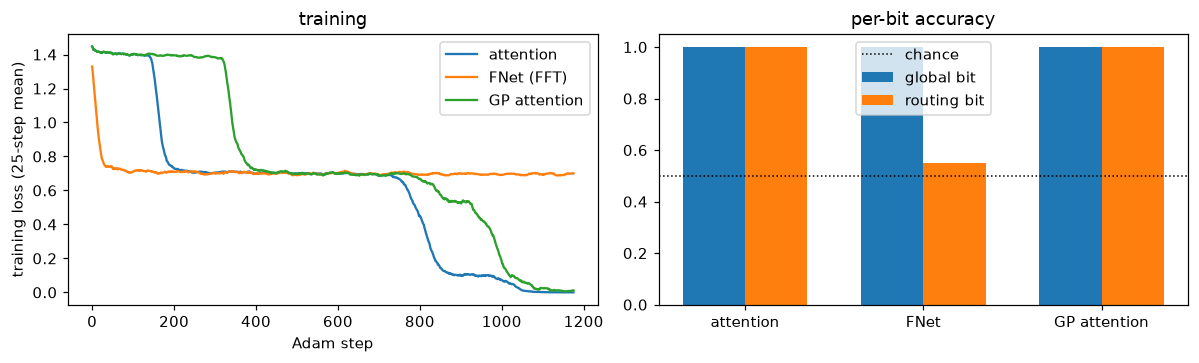

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for kind, lab in [("attn", "attention"), ("fnet", "FNet (FFT)"), ("gpa", "GP attention")]:
    cur = np.convolve(curves[kind], np.ones(25) / 25, mode="valid")
    ax[0].plot(cur, label=lab)
ax[0].set_xlabel("Adam step"); ax[0].set_ylabel("training loss (25-step mean)"); ax[0].legend()
ax[0].set_title("training")
w = 0.35; idx = np.arange(3)
kinds = ["attn", "fnet", "gpa"]
ax[1].bar(idx - w/2, [R[k]["acc_global"] for k in kinds], w, label="global bit")
ax[1].bar(idx + w/2, [R[k]["acc_route"] for k in kinds], w, label="routing bit")
ax[1].axhline(0.5, color="k", ls=":", lw=1, label="chance")
ax[1].set_xticks(idx); ax[1].set_xticklabels(["attention", "FNet", "GP attention"])
ax[1].set_ylim(0, 1.05); ax[1].legend(); ax[1].set_title("per-bit accuracy")
plt.tight_layout(); plt.show()

### Reading the dissociation

FNet is not a weaker model here. It is a model with a **different reachable set**. Its mixing weights do
not depend on the input, so no amount of training can make it look at position 37 when the query says 37
and position 12 when the query says 12. That is not a capacity limitation; it is what "content-independent"
means, and it is the exact property that makes the FFT cost $O(N \log N)$ instead of $O(N^2)$.

Meanwhile FNet is *perfect* on the global bit — the component that is a fixed linear functional of all
positions — and it gets there with **zero parameters in the mixer**. All three models solve that bit —
1.000 / 0.999 / 0.999, which is why the three left-hand bars above are equal — and that is the point rather
than an accident: FNet is not *better* on the global bit, it matches the learned mixers there **for free**.
That is the FNet paper's real claim, reproduced at toy scale: a large fraction of what mixing layers do is
fixed global aggregation, and you can have that fraction for free.

Its routing score is not mystery signal, either: 0.55 is exactly the linear-leak ceiling measured
above — the one content-independent read the task admits — and where FNet lands inside [0.50, 0.55]
varies with the evaluation draw (a different seed later in this notebook puts it at 0.50). The
ceiling, not the point value, is the claim.

This is why the flagship argues that "is attention obsolete?" is the wrong question. The useful axis is how
much of your mixing needs to be content-dependent, and this task splits that axis into two measurable bits.

---

## 4. Cost: the asymptotics are real and they arrive late

$O(N \log N)$ beats $O(N^2)$, so the FFT mixer should win — but by how much, and starting where? We time
the **mixer alone** and the **whole block**, because they answer different questions. The mixer-alone number
is the architectural comparison. The whole-block number is the one that decides whether rewriting your model
is worth it, because the feed-forward network does not get cheaper either way.

The last column is the FLOP-count prediction, $N / \log_2 N$.

In [7]:
BS_T = 2
rows = []
rng = np.random.default_rng(5)
print(f"{'N':>7} {'mix attn':>10} {'mix fnet':>10} {'mix gpa':>10} {'mix x':>8} "
      f"{'blk attn':>10} {'blk fnet':>10} {'blk x':>8} {'N/log2N':>9}")
for N in [64, 256, 1024, 4096, 8192]:
    Z = rng.normal(0, 1, (BS_T, N, D_MODEL))
    pa = init_params("attn", 0, seq_len=N)
    reps = 5 if N <= 1024 else 3
    t = {}
    for kind in ["attn", "fnet", "gpa"]:
        mix(kind, pa, Z); forward(kind, pa, Z)                  # warm-up: never time a cold cache
        for tag, fn in (("mix", mix), ("blk", forward)):
            b = np.inf
            for _ in range(reps):
                t0 = time.perf_counter(); fn(kind, pa, Z); b = min(b, time.perf_counter() - t0)
            t[f"{tag}_{kind}"] = b * 1000 / BS_T
    rows.append((N, t))
    print(f"{N:>7} {t['mix_attn']:>10.3f} {t['mix_fnet']:>10.3f} {t['mix_gpa']:>10.3f} "
          f"{t['mix_attn']/t['mix_fnet']:>8.1f} {t['blk_attn']:>10.3f} {t['blk_fnet']:>10.3f} "
          f"{t['blk_attn']/t['blk_fnet']:>8.2f} {N/np.log2(N):>9.1f}")
print("\nmilliseconds per sequence, min over the reps, one laptop CPU via NumPy's BLAS.")
print("Measurement note: at large N the block is mixer-dominated, so mix and blk timings can")
print("invert within a few percent of run-to-run noise -- read magnitudes, not third digits.")

small = rows[0][1]; big = rows[-1][1]
r_small = small['blk_attn'] / small['blk_fnet']
r_big = big['blk_attn'] / big['blk_fnet']
print(f"\nWhole-block speed-up from FFT mixing: {r_small:.2f}x at N={rows[0][0]}, "
      f"{r_big:.1f}x at N={rows[-1][0]}.")
if r_small < 1.0:
    print(f"At N={rows[0][0]} the FFT block is actually SLOWER ({1/r_small:.2f}x) than the attention block.")
naive = rows[-1][0] / np.log2(rows[-1][0])
print(f"A constants-free N^2/(N log2 N) ratio at N={rows[-1][0]} is {naive:.0f}x; the whole block gains")
print(f"{r_big:.1f}x and the mixer alone {big['mix_attn']/big['mix_fnet']:.0f}x. The block-vs-ratio gap is mostly Amdahl -- the")
print("feed-forward stage is untouched -- and the ratio itself carries no constants, no d and no")
print("memory-bandwidth currency, so treat it as a slope, never as a predicted speed-up.")

      N   mix attn   mix fnet    mix gpa    mix x   blk attn   blk fnet    blk x   N/log2N
     64      0.091      0.035      0.111      2.6      0.175      0.405     0.43      10.7


    256      2.133      0.107      2.667     19.9      4.722      1.115     4.24      32.0


   1024     28.994      0.760     34.819     38.1     32.979      3.548     9.29     102.4


   4096    435.286      4.218    515.158    103.2    435.738     13.706    31.79     341.3


   8192   3166.088     12.502   3955.163    253.3   3150.534     33.361    94.44     630.2

milliseconds per sequence, min over the reps, one laptop CPU via NumPy's BLAS.
Measurement note: at large N the block is mixer-dominated, so mix and blk timings can
invert within a few percent of run-to-run noise -- read magnitudes, not third digits.

Whole-block speed-up from FFT mixing: 0.43x at N=64, 94.4x at N=8192.
At N=64 the FFT block is actually SLOWER (2.32x) than the attention block.
A constants-free N^2/(N log2 N) ratio at N=8192 is 630x; the whole block gains
94.4x and the mixer alone 253x. The block-vs-ratio gap is mostly Amdahl -- the
feed-forward stage is untouched -- and the ratio itself carries no constants, no d and no
memory-bandwidth currency, so treat it as a slope, never as a predicted speed-up.


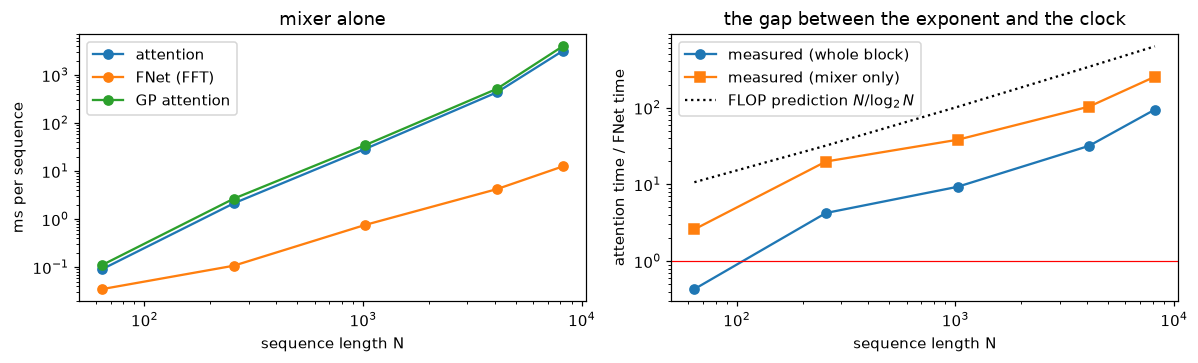

In [8]:
Ns = [r[0] for r in rows]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for key, lab in [("mix_attn", "attention"), ("mix_fnet", "FNet (FFT)"), ("mix_gpa", "GP attention")]:
    ax[0].loglog(Ns, [r[1][key] for r in rows], "o-", label=lab)
ax[0].set_xlabel("sequence length N"); ax[0].set_ylabel("ms per sequence")
ax[0].set_title("mixer alone"); ax[0].legend()
ax[1].loglog(Ns, [r[1]["blk_attn"] / r[1]["blk_fnet"] for r in rows], "o-", label="measured (whole block)")
ax[1].loglog(Ns, [r[1]["mix_attn"] / r[1]["mix_fnet"] for r in rows], "s-", label="measured (mixer only)")
ax[1].loglog(Ns, [N / np.log2(N) for N in Ns], "k:", label=r"FLOP prediction $N/\log_2 N$")
ax[1].axhline(1.0, color="r", lw=0.8)
ax[1].set_xlabel("sequence length N"); ax[1].set_ylabel("attention time / FNet time")
ax[1].set_title("the gap between the exponent and the clock"); ax[1].legend()
plt.tight_layout(); plt.show()

> **Engineering callout #1 — the exponent is a promise about slopes, not about your sequence length.**
>
> Two effects pull the measured gain below the FLOP ratio, and they pull in the same direction at every
> length we tested. First, the feed-forward network costs the same in both models, so removing the entire
> mixing cost cannot speed the block up by more than the fraction the mixer accounted for — the ordinary
> ceiling on optimising one stage of a pipeline. Second, dense matrix multiplication runs at near-peak
> throughput through a tuned BLAS, while the FFT is memory-bandwidth-bound with strided access; the two
> operations are not paid for in the same currency.
>
> At the short end the effects are large enough to reverse the sign of the decision. Read the plot, not
> the exponent, and measure on the hardware you will actually deploy to.

---

## 5. Knowing that you do not know

Now the axis the plan promised GP attention would win, where the measurement had something to say.

The out-of-distribution test is a one-line change to the data generator: **do not plant the matching key.**
The query at position 0 asks for a key that appears in none of the 63 slots. The global bit is untouched and
still readable; the routing bit has no correct answer to find. A model that understands its own mechanism
should become uncertain about exactly one of the two bits.

In [9]:
def ece(probs, y, bins=10):
    conf, pred = probs.max(1), probs.argmax(1)
    correct = (pred == y).astype(float); e = 0.0
    for b in range(bins):
        sel = (conf > b / bins) & (conf <= (b + 1) / bins)
        if sel.sum():
            e += sel.sum() / len(y) * abs(correct[sel].mean() - conf[sel].mean())
    return float(e)

print(f"{'mixer':>6} {'ID routing':>12} {'OOD routing':>13} {'OOD conf':>10} {'ECE id':>9} {'ECE ood':>9}")
store = {}
for kind in ["attn", "fnet", "gpa"]:
    r_id, P_id, y_id, X_id = evaluate(kind, models[kind], n=1024, seed=4242, ood=False)
    r_od, P_od, y_od, X_od = evaluate(kind, models[kind], n=1024, seed=4242, ood=True)
    store[kind] = (P_id, y_id, X_id, P_od, y_od, X_od)
    print(f"{kind:>6} {r_id['acc_route']:>12.3f} {r_od['acc_route']:>13.3f} {r_od['conf']:>10.3f} "
          f"{ece(P_id, y_id):>9.3f} {ece(P_od, y_od):>9.3f}")

pa_id, _, _, pa_od, _, _ = store["attn"]
print(f"\nAttention on OOD data: {evaluate('attn', models['attn'], n=1024, seed=4242, ood=True)[0]['acc_route']:.1%} "
      f"correct on the routing bit while reporting {pa_od.max(1).mean():.1%} mean confidence.")
print("Calibrated in distribution, badly overconfident out of it. This is the ordinary behaviour of a")
print("softmax head, and it is why the softmax probability is not an uncertainty estimate.")

 mixer   ID routing   OOD routing   OOD conf    ECE id   ECE ood


  attn        1.000         0.502      0.915     0.000     0.413


  fnet        0.501         0.467      0.544     0.044     0.077


   gpa        1.000         0.479      0.911     0.001     0.435



Attention on OOD data: 50.2% correct on the routing bit while reporting 91.5% mean confidence.
Calibrated in distribution, badly overconfident out of it. This is the ordinary behaviour of a
softmax head, and it is why the softmax probability is not an uncertainty estimate.


In [10]:
def auroc(score_pos, score_neg):
    # probability a random OOD example scores higher than a random ID example
    return float((score_pos[:, None] > score_neg[None, :]).mean()
                 + 0.5 * (score_pos[:, None] == score_neg[None, :]).mean())

def routing_stats(kind, X):
    p = models[kind]
    Q, K = X @ p["Wq"], X @ p["Wk"]
    q0, Kk = Q[:, 0:1, :], K[:, 1:, :]
    if kind == "attn":
        S = (q0 * Kk).sum(-1) / np.sqrt(D_MODEL)
    else:
        S = -((q0 - Kk) ** 2).sum(-1) / (2 * LS ** 2)
    A = softmax(S)
    return A.max(1), -(A * np.log(np.maximum(A, 1e-12))).sum(1)

def gp_posterior_var(X, ls, jitter=1e-4):
    p = models["gpa"]
    Q, K = X @ p["Wq"], X @ p["Wk"]
    q0, Kk = Q[:, 0:1, :], K[:, 1:, :]
    kq = np.exp(-((q0 - Kk) ** 2).sum(-1) / (2 * ls ** 2))
    d2 = ((Kk[:, :, None, :] - Kk[:, None, :, :]) ** 2).sum(-1)
    Km = np.exp(-d2 / (2 * ls ** 2)) + jitter * np.eye(Kk.shape[1])
    return 1.0 - np.einsum('ni,ni->n', kq, np.linalg.solve(Km, kq[..., None])[..., 0])

print("OOD detection AUROC  (0.500 = a coin flip, 1.000 = perfect separation)\n")
print(f"{'mixer':>6}  {'signal':<46} {'AUROC':>7}")
peaks = {}
for kind in ["attn", "fnet", "gpa"]:
    P_id, _, X_id, P_od, _, X_od = store[kind]
    print(f"{kind:>6}  {'1 - softmax confidence':<46} {auroc(1-P_od.max(1), 1-P_id.max(1)):>7.3f}")
    if kind == "fnet":
        print(f"{'':>6}  {'(FNet has no routing distribution to inspect)':<46} {'--':>7}")
        continue
    a_id, h_id = routing_stats(kind, X_id)
    a_od, h_od = routing_stats(kind, X_od)
    peaks[kind] = (a_id.mean(), a_od.mean())
    print(f"{'':>6}  {'1 - peak routing weight':<46} {auroc(1-a_od, 1-a_id):>7.3f}")
    print(f"{'':>6}  {'routing entropy':<46} {auroc(h_od, h_id):>7.3f}")
    if kind == "gpa":
        best = max((auroc(gp_posterior_var(X_od, ls), gp_posterior_var(X_id, ls)), ls)
                   for ls in [1, 2, 4, 8, 16, 32])
        print(f"{'':>6}  {f'GP posterior variance (best of 6 lengthscales, l={best[1]})':<46} {best[0]:>7.3f}")
    print()

print(f"mean peak routing weight -- attention: ID {peaks['attn'][0]:.3f}  OOD {peaks['attn'][1]:.3f}")
print(f"                         GP attention: ID {peaks['gpa'][0]:.3f}  OOD {peaks['gpa'][1]:.3f}")
print(f"                     uniform over {L-1} slots = {1/(L-1):.3f}")

OOD detection AUROC  (0.500 = a coin flip, 1.000 = perfect separation)

 mixer  signal                                           AUROC
  attn  1 - softmax confidence                           0.949
        1 - peak routing weight                          1.000
        routing entropy                                  0.993

  fnet  1 - softmax confidence                           0.495
        (FNet has no routing distribution to inspect)       --


   gpa  1 - softmax confidence                           0.901


        1 - peak routing weight                          1.000
        routing entropy                                  0.948


        GP posterior variance (best of 6 lengthscales, l=2)   0.657

mean peak routing weight -- attention: ID 0.700  OOD 0.090
                         GP attention: ID 0.372  OOD 0.053
                     uniform over 63 slots = 0.016


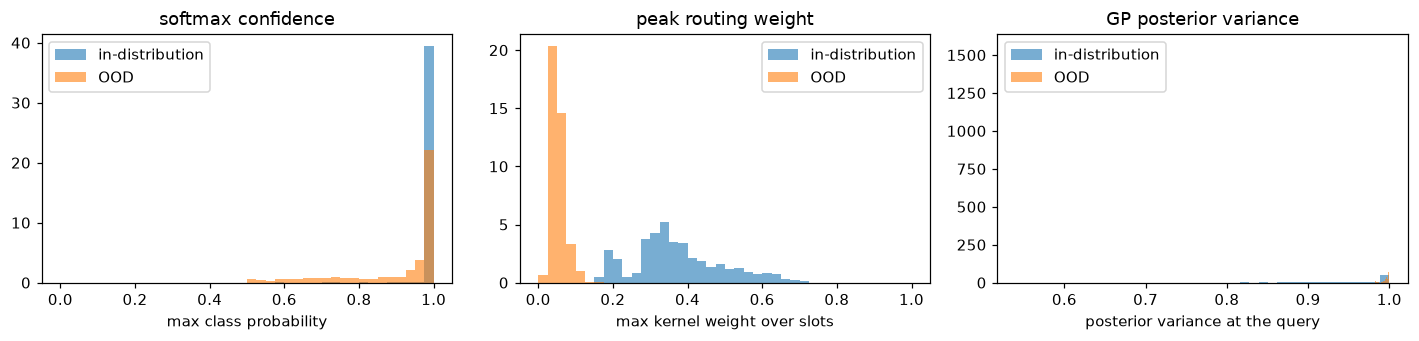

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
P_id, _, X_id, P_od, _, X_od = store["gpa"]
a_id, h_id = routing_stats("gpa", X_id); a_od, h_od = routing_stats("gpa", X_od)
bins = np.linspace(0, 1, 41)
ax[0].hist(P_id.max(1), bins=bins, alpha=0.6, label="in-distribution", density=True)
ax[0].hist(P_od.max(1), bins=bins, alpha=0.6, label="OOD", density=True)
ax[0].set_title("softmax confidence"); ax[0].set_xlabel("max class probability"); ax[0].legend()
ax[1].hist(a_id, bins=bins, alpha=0.6, label="in-distribution", density=True)
ax[1].hist(a_od, bins=bins, alpha=0.6, label="OOD", density=True)
ax[1].set_title("peak routing weight"); ax[1].set_xlabel("max kernel weight over slots"); ax[1].legend()
vid = gp_posterior_var(X_id, 4.0); vod = gp_posterior_var(X_od, 4.0)
ax[2].hist(vid, bins=40, alpha=0.6, label="in-distribution", density=True)
ax[2].hist(vod, bins=40, alpha=0.6, label="OOD", density=True)
ax[2].set_title("GP posterior variance"); ax[2].set_xlabel("posterior variance at the query"); ax[2].legend()
plt.tight_layout(); plt.show()

> **Engineering callout #2 — the principled uncertainty estimate lost to the crude one.**
>
> The plan for this notebook predicted that GP attention would be the model with usable uncertainty,
> via its closed-form posterior variance. The measurement says something more useful and less flattering.
>
> The **GP posterior variance is close to useless here**, even after sweeping the lengthscale over six
> values and reporting the best. The reason is visible once you write it down: the posterior variance
> measures how well the query is *covered by the key set as a whole*. Sixty-three keys at moderate
> distance provide about as much coverage whether or not one of them is an exact match, so the quantity
> that distinguishes the two cases gets averaged away.
>
> The **peak routing weight separates the two sets perfectly**, and attention's dot-product routing does
> it just as well as the RBF version. The reason is the softmax: it normalises, so what survives is the
> *contrast* between the best key and the rest — which is precisely where the routing signal lives. An
> absolute quantity washed it out; a relative one recovered it exactly.
>
> The practical rule: when a kernel-view model offers you uncertainty, ask which functional of the kernel
> you are reading, and check it against the failure you actually care about. "It is a Gaussian process so
> it has principled error bars" is not, by itself, a measurement.

> **Engineering callout #3 — FNet cannot fail this way because it cannot try.**
>
> FNet's softmax-confidence AUROC sits at chance. This is not a tuning problem and no amount of training
> will move it. FNet has **no data-dependent weights anywhere in its mixer**, so there is no routing
> distribution to interrogate — nothing in the layer changes when the query matches nothing, because
> nothing in the layer ever depended on the query.
>
> That is the price of the $O(N \log N)$, stated exactly. The property that makes fixed spectral mixing
> cheap is the same property that removes the signal you would use to detect that it is out of its depth.
> It is a genuine trade, not a defect, and it belongs in the decision alongside the FLOP count.

---

## 6. Why these three belong in the same notebook

The connection is not that all three "mix tokens". It is a chain of identities.

**Attention is kernel regression.** Softmax attention computes
$\sum_j \frac{\kappa(q_i,k_j)}{\sum_{j'}\kappa(q_i,k_{j'})} v_j$ with $\kappa(q,k)=\exp(q^\top k/\sqrt d)$ —
the Nadaraya–Watson estimator. Our GP-attention mixer is the same estimator with $\kappa$ swapped for an
RBF; that is a two-line change in `mix()` and nothing else in the code moves.

**Bochner turns the kernel into frequencies.** An RBF kernel is stationary and positive definite, so by
Bochner's theorem it *is* the Fourier transform of a probability density over frequencies, and
$\kappa(q,k)=\mathbb{E}_\omega[\cos(\omega^\top(q-k))]$. Kernel attention is therefore already an operation
in the frequency domain — implicitly, through an expectation, rather than through a call to an FFT. NB 00
made that expectation explicit and sampled it.

**FNet is the fixed limit.** Replace the content-dependent kernel with a fixed global mixing operation and
apply the convolution theorem, and you get a DFT: every position sees every other, at $O(N \log N)$, with
no parameters. What you drop is the dependence on content — and the routing-bit column above is the price,
measured.

So the three columns are one family, ordered by how much of the mixing is allowed to depend on the data:
**all of it** (attention, GP attention) or **none of it** (FNet). Real 2026 architectures sit along that
line rather than at its ends — a state-space model is a learned filter that mostly does not adapt, and
Mamba's selectivity is exactly the decision to buy back some adaptivity at some cost.

## 7. What to take away

- **Report per-capability accuracy, not aggregate accuracy.** FNet's overall number looks like a mediocre
  model. The breakdown shows a model that is perfect at one thing and structurally incapable of the other.
  Only one of those descriptions helps you choose.
- **Content-independent mixing is cheap and it is a real constraint.** Fixed global aggregation is close to
  free and covers more of what mixing layers do than the architecture literature implies. It cannot do
  input-dependent routing, at any width or step count.
- **Measure the crossover; do not infer it from the exponent.** The whole-block advantage we measured runs
  well below the FLOP-count prediction at every length, and at short sequences it is below one.
- **Ask which uncertainty functional you are reading.** The textbook posterior variance lost to the peak
  routing weight by a wide margin, and the crude quantity was the correct one for this failure mode.
- **A model with nothing data-dependent has nothing to tell you.** FNet's inability to signal OOD is a
  consequence of its cost advantage, not an accident of this implementation.

Start here if you have not: **[NB 00 — Fourier Features from Scratch](00_fourier_features_from_scratch.ipynb)**.

**Further reading.** [FNet: Mixing Tokens with Fourier Transforms (arXiv:2105.03824)](https://arxiv.org/abs/2105.03824) ·
[Global Filter Networks (arXiv:2107.00645)](https://arxiv.org/abs/2107.00645) ·
[Hyena Hierarchy (arXiv:2302.10866)](https://arxiv.org/abs/2302.10866) ·
[Mamba (arXiv:2312.00752)](https://arxiv.org/abs/2312.00752) ·
[Random Features for Large-Scale Kernel Machines (Rahimi & Recht, 2007)](https://papers.nips.cc/paper_files/paper/2007/hash/013a006f03dbc5392effeb8f18fda755-Abstract.html)

Our earlier weeks this notebook builds on:
[Attention is a kernel](https://artifocial.com/blog/attention-is-a-kernel-2026-jul-12) ·
[Why uncertainty matters](https://artifocial.com/blog/why-uncertainty-matters-2026-jul-13) ·
[Post-transformer architectures](https://artifocial.com/blog/post-transformer-architectures-2026-apr-09)